In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from itertools import product

In [ ]:
def encoding(bit_string, d): #Encoding function
    encoded_string = []
    for bit in bit_string:
        encoded_string.extend([bit] * d)  # Repeat each bit d times
    return encoded_string

def error_sampling(bit_string, p): #Error sampling function
    after_error = []
    for bit in bit_string:
        if np.random.rand() < p:
            after_error.append(1 - bit)  # Flip the bit
        else:
            after_error.append(bit)  # Keep the bit unchanged
    return after_error

def syndrome_measurement(block):
    s=[]
    for i in range(0, len(block)-1):
        s.append(block[i] ^ block[i+1])  # XOR operation for syndrome measurement
    return s    

def build_single_error_lookup_table(d):
    table = {}

    no_error = [0] * d
    no_syndrome = tuple(syndrome_measurement(no_error))
    table[no_syndrome] = [0] * d

    for error_position in range(d):
        error = [0] * d
        error[error_position] = 1

        syndrome = tuple(syndrome_measurement(error))
        table[syndrome] = error

    return table

def weight(error):
    return sum(error)

def build_minimum_weight_lookup_table(d):
    table = {}

    for error in product([0, 1], repeat=d):
        error = list(error)
        syndrome = tuple(syndrome_measurement(error))

        if syndrome not in table:
            table[syndrome] = error
        else:
            if weight(error) < weight(table[syndrome]):
                table[syndrome] = error

    return table

def decoding_list(syndrome, lookup_table):
    syndrome_tuple = tuple(syndrome)
    if syndrome_tuple in lookup_table:
        return lookup_table[syndrome_tuple]

def error_correction_block(received_block, lookup_table):
    syndrome = syndrome_measurement(received_block)
    error_pattern = decoding_list(syndrome, lookup_table)
    if error_pattern is not None:
        corrected_block = [(received_block[i] ^ error_pattern[i]) for i in range(len(received_block))]
        return corrected_block
    else:
        return received_block  # No correction if syndrome not found

def error_correction_message(received_message, lookup_table, d):
    # lookup_table = build_minimum_weight_lookup_table(d)
    corrected_message = []
    for i in range(0, len(received_message), d):
        block = received_message[i:i+d]
        corrected_block = error_correction_block(block, lookup_table)
        corrected_message.extend(corrected_block)  # Take the first bit of each block
    return corrected_message



Estimated a for d=3: 2.4713448137976495
Quality of fit for d=3: 3.470068042688231e-05
Estimated a for d=5: 6.496697624623165
Quality of fit for d=5: 4.7882364435685006e-05
Estimated a for d=7: 17.44379471261647
Quality of fit for d=7: 2.161074338008874e-05
Estimated a for d=9: 44.0441980041041
Quality of fit for d=9: 1.6195872789084413e-05
Estimated a for d=11: 121.55760575281124
Quality of fit for d=11: 1.010542513166456e-05


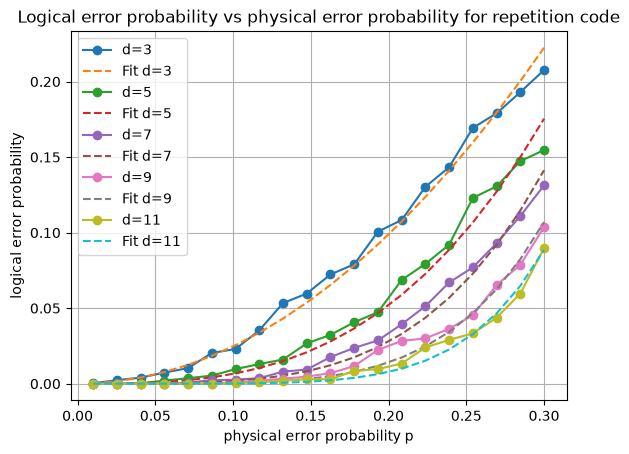

In [ ]:
message = [0]

def trial(lookup_table,d,p):
    encoded = encoding(message, d)
    noisy = error_sampling(encoded, p)
    corrected = error_correction_message(noisy, lookup_table, d)
    return corrected == encoded

def error_rate(lookup_table, d, p, trials=1000):
    successes = sum(trial(lookup_table, d, p) for _ in range(trials))
    return 1 - (successes / trials)

ps = np.linspace(0.01, 0.3, 20)
ds = [3, 5, 7, 9, 11]
shots = 3000
message = [1]

for d in ds:
    rates = []
    lookup_table = build_minimum_weight_lookup_table(d)
    for p in ps:
        rates.append(error_rate(lookup_table, d, p, trials=shots))
    
    #estimating the logical error probability using the formula p_L = a * p^(d+1)/2
    exponent = (d + 1) // 2
    x = ps ** exponent
    y = rates
    a = sum(x*y) / sum(x*x)
    print(f"Estimated a for d={d}: {a}")
    print(f"Quality of fit for d={d}: {sum((y - a * x) ** 2) / len(y)}")
    plt.plot(ps, rates, marker="o", label=f"d={d}")
    plt.plot(ps, a * ps ** exponent, linestyle="--", label=f"Fit d={d}")

plt.xlabel("physical error probability p")
plt.ylabel("logical error probability")
plt.title("Logical error probability vs physical error probability for repetition code")
plt.legend()
plt.grid(True)
plt.show()